In [1]:
import gymnasium as gym
import math
import random
import matplotlib
import matplotlib.pyplot as plt
from collections import namedtuple, deque
from itertools import count

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

env = gym.make("Acrobot-v1")

# set up matplotlib (I don't actually know how this works - Merrick, 04/24/2026)
is_ipython = 'inline' in matplotlib.get_backend()
if is_ipython:
    from IPython import display

# Set device to cpu because my computer doesn't have gpu for cuda
device = torch.device("cpu")

In [2]:
Transition = namedtuple('Transition',
                        ('state', 'action', 'next_state', 'reward'))


class ReplayMemory(object):

    def __init__(self, capacity):
        self.memory = deque([], maxlen=capacity)

    def push(self, *args):
        """Save a transition"""
        self.memory.append(Transition(*args))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)

In [3]:
class DQN(nn.Module):

    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super(DQN, self).__init__()

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [4]:
BATCH_SIZE = 128    # number of transitions sampled from replay buffer
GAMMA = 0.99        # discount factor; influences how "far-sighted" the model is
EPS_START = 0.9     # starting chance of a random action
EPS_END = 0.01      # minimum chance of a random action during training
EPS_DECAY = 2500    # rate of exponential decay of epsilon; higher means a slower decay
TAU = 0.005         # update rate of the target network
LR = 3e-4           # learning rate of the optimizer

# Get number of actions from gymnasium action space
n_actions = env.action_space.n
# Get the number of elements encoding state in one observation
n_observations = env.observation_space.shape[0]

policy_net = DQN(n_observations, n_actions).to(device)
target_net = DQN(n_observations, n_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.AdamW(policy_net.parameters(), lr=LR, amsgrad=True)
memory = ReplayMemory(10000)

steps_done = 0

def select_action(state):
    global steps_done
    sample = random.random()
    eps_threshold = EPS_END + (EPS_START - EPS_END) * math.exp(-1. * steps_done / EPS_DECAY)
    steps_done += 1
    if sample > eps_threshold:
        with torch.no_grad():
            return policy_net(state).max(1).indices.view(1, 1)
    else:
        return torch.tensor([[env.action_space.sample()]], device=device, dtype=torch.long)


episode_durations = []
episode_rewards = []


# I also don't know how this function works - Merrick, 04/24/2026
def plot_rewards(show_result=False):
    plt.figure(1)
    rewards = torch.tensor(episode_rewards, dtype=torch.float)
    if show_result:
        plt.title('Result')
    else:
        plt.clf()
        plt.title('Training...')
    plt.xlabel('Episode')
    plt.ylabel('Reward')
    plt.plot(rewards.numpy())
    # Take 100 episode averages and plot them too
    if len(rewards) >= 100:
        means = rewards.unfold(0, 100, 1).mean(1).view(-1)
        means = torch.cat((torch.full((99,), -500), means))
        plt.plot(means.numpy())
        plt.title(f"Mean Reward over Last 100 episodes: {means.numpy()[-1]:.2f}")

    plt.savefig('training_progress.png')
    
    plt.pause(0.001)  # pause a bit so that plots are updated
    if is_ipython:
        if not show_result:
            display.display(plt.gcf())
            display.clear_output(wait=True)
        else:
            display.display(plt.gcf())

In [5]:
def optimize_model():
    if len(memory) < BATCH_SIZE:
        return
    transitions = memory.sample(BATCH_SIZE)
    # Convert batch-array of Transitions to 
    # Transition of batch-arrays: https://stackoverflow.com/a/19343/3343043
    batch = Transition(*zip(*transitions))

    # Compute a mask of non-final states and concatenate the batch elements
    # (a final state would've been the one after which simulation ended)
    non_final_mask = torch.tensor(tuple(map(lambda s: s is not None,
                                            batch.next_state)), device=device, dtype=torch.bool)
    non_final_next_states = torch.cat([s for s in batch.next_state if s is not None])
    state_batch = torch.cat(batch.state)
    action_batch = torch.cat(batch.action)
    reward_batch = torch.cat(batch.reward)

    # Compute Q(s_t, a) with the policy network
    state_action_values = policy_net(state_batch).gather(1, action_batch)

    # Compute V(s_{t+1} for all next states.
    # These are the expected values for actions for non-final-next-states.
    # Use zeros for final states.
    next_state_values = torch.zeros(BATCH_SIZE, device=device)
    with torch.no_grad():
        next_state_values[non_final_mask] = target_net(non_final_next_states).max(1).values
    # Compute the expected Q values
    expected_state_action_values = (next_state_values * GAMMA) + reward_batch

    # Compute Huber loss
    criterion = nn.SmoothL1Loss()
    loss = criterion(state_action_values, expected_state_action_values.unsqueeze(1))

    # Optimize the model
    optimizer.zero_grad()
    loss.backward()
    # In-place gradient clipping
    torch.nn.utils.clip_grad_value_(policy_net.parameters(), 100)
    optimizer.step()

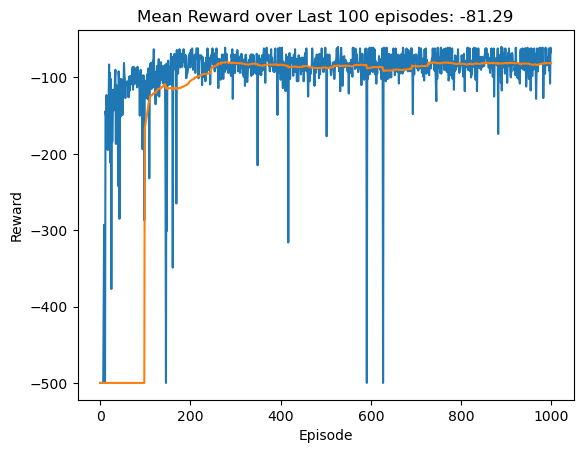

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [6]:
num_episodes = 1000

for i_episode in range(num_episodes):
    # Initialize the environment and get its state
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    episode_reward = 0
    for t in count():
        action = select_action(state)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        episode_reward += reward
        reward = torch.tensor([reward], device=device)
        done = terminated or truncated

        if terminated:
            next_state = None
        else:
            next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
    
        # Store the transition in memory
        memory.push(state, action, next_state, reward)

        # Move to the next state
        state = next_state

        # Perform one step of the optimization (on the policy network)
        optimize_model()

        # Soft update the target network's weights
        # θ′ ← τ θ + (1 −τ )θ′
        target_net_state_dict = target_net.state_dict()
        policy_net_state_dict = policy_net.state_dict()
        for key in policy_net_state_dict:
            target_net_state_dict[key] = policy_net_state_dict[key] * TAU + target_net_state_dict[key] * (1 - TAU)
        target_net.load_state_dict(target_net_state_dict)

        if done:
            episode_durations.append(t + 1)
            episode_rewards.append(episode_reward)
            plot_rewards()
            break
plot_rewards(show_result=True)
torch.save(policy_net.state_dict(), 'acrobot_weights_and_biases.pth')

In [7]:
env = gym.make("Acrobot-v1", render_mode="human")
n_actions = env.action_space.n
n_observations = env.observation_space.shape[0]

model = DQN(n_observations, n_actions).to(device)
model.load_state_dict(torch.load('acrobot_weights_and_biases.pth', weights_only=False))
model.eval()

for i in range(5):
    state, info = env.reset()
    state = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    
    terminated = False
    truncated = False

    episode_reward = 0
    
    while not terminated or truncated:
        with torch.no_grad():
            action = model(state).max(1).indices.view(1, 1)
        observation, reward, terminated, truncated, _ = env.step(action.item())
        next_state = torch.tensor(observation, dtype=torch.float32, device=device).unsqueeze(0)
        state = next_state
        episode_reward += reward
    print(f"Episode Reward: {episode_reward:0.0f}")
env.close()

C:\Users\Merrick\anaconda3\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Episode Reward: -84
Episode Reward: -62
Episode Reward: -62
Episode Reward: -83
Episode Reward: -60
